In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [3]:
# width = 1200
height = 1800
# cutout_left = 900
# cutout_top = 800
width = 1500
# height = 1500
cutout_left = 1000
cutout_top = 500

In [4]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')
low_probability = 10 ** -10

In [5]:
wx_map > 0

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

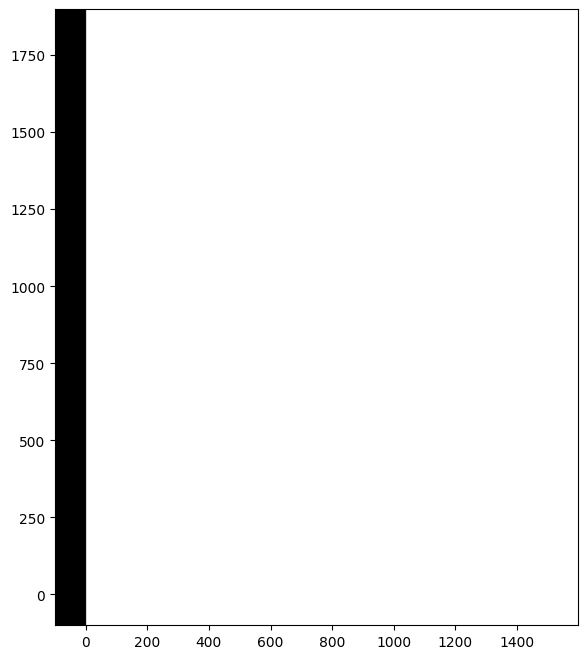

In [6]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )
plot_map(wx_map > 0)

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

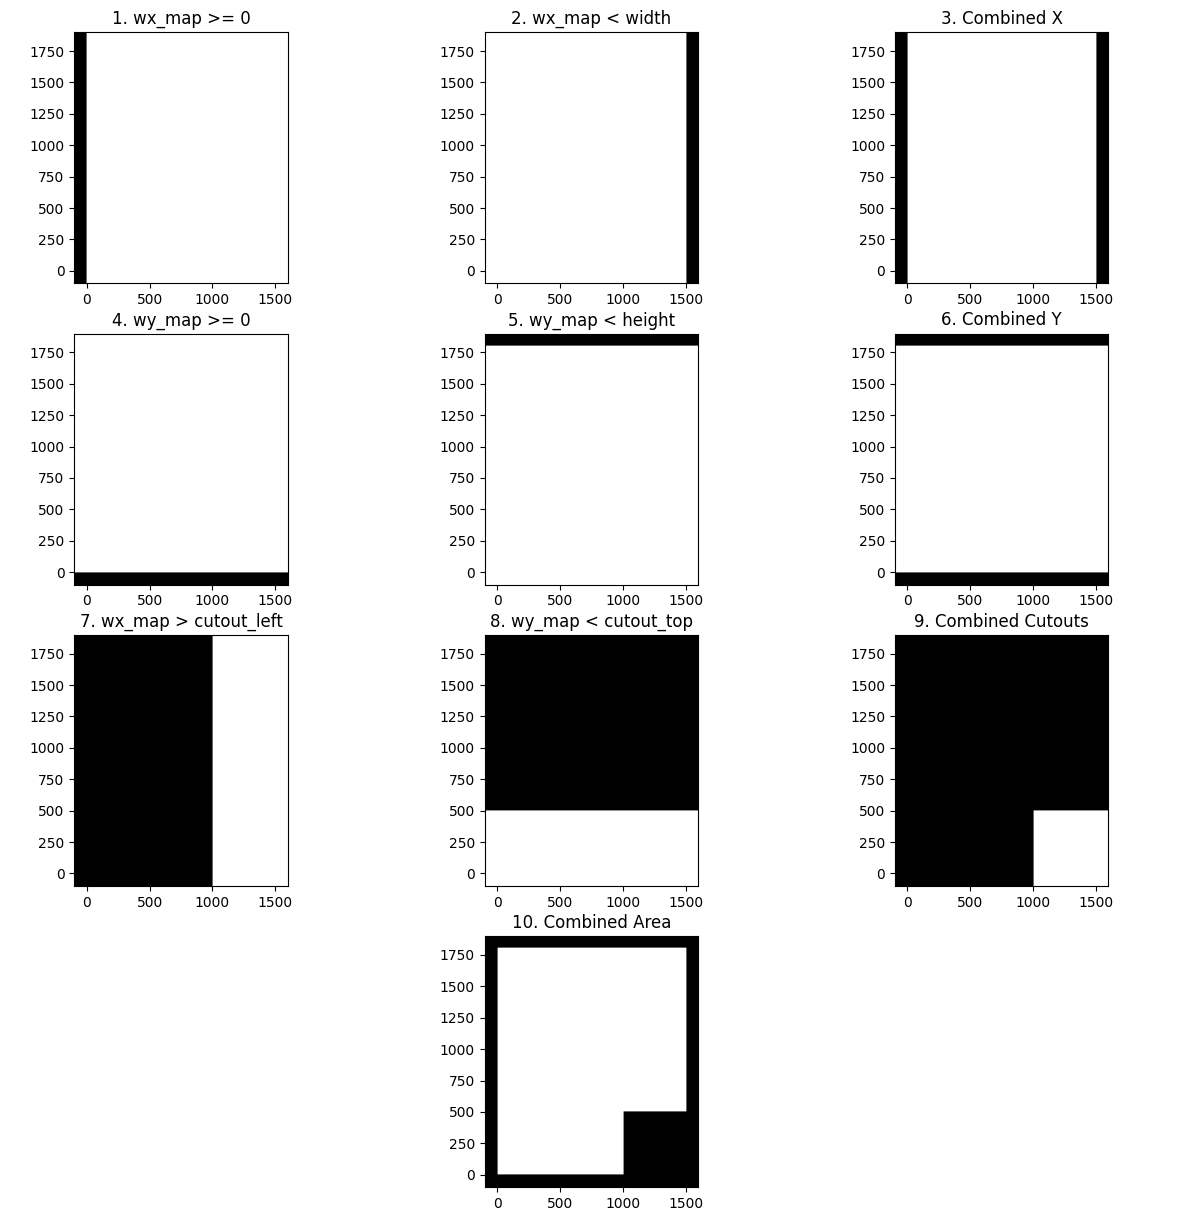

In [7]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))

# X axis
plot_map(wx_map >= 0, axs=axs[0, 0], title='1. wx_map >= 0')
plot_map(wx_map < width, axs=axs[0, 1], title='2. wx_map < width')
combined_x = (wx_map >= 0) & (wx_map < width)
plot_map(combined_x, axs=axs[0, 2], title='3. Combined X')

# Y axis
plot_map(wy_map >= 0, axs=axs[1, 0], title='4. wy_map >= 0')
plot_map(wy_map < height, axs=axs[1, 1], title='5. wy_map < height')
combined_y = (wy_map >= 0) & (wy_map < height)
plot_map(combined_y, axs=axs[1, 2], title='6. Combined Y')

# Cutouts
plot_map(wx_map > cutout_left, axs=axs[2, 0], title='7. wx_map > cutout_left')
plot_map(wy_map < cutout_top, axs=axs[2, 1], title='8. wy_map < cutout_top')
combined_cutouts = (wx_map > cutout_left) & (wy_map < cutout_top)
plot_map(combined_cutouts, axs=axs[2, 2], title='9. Combined Cutouts')

# Combinations
combined_area = combined_x & combined_y & ~combined_cutouts
plot_map(combined_area, axs=axs[3, 1], title='10. Combined Area')
# Hide unused subplots
axs[3, 0].axis('off')
axs[3, 2].axis('off')


In [8]:
inside_boundary_field = np.full_like(wx_map, low_probability, dtype=np.float32)
inside_boundary_field[combined_area] = 1.0

In [9]:
print("World (1200, 200) = ", inside_boundary_field[margin + 1200, margin + 200])
print("World (-1, 0) = ", inside_boundary_field[margin - 1, margin])
print("World (0, 0) = ", inside_boundary_field[margin, margin])
print("World (1, 0) = ", inside_boundary_field[margin + 1, margin])

World (1200, 200) =  1e-10
World (-1, 0) =  1e-10
World (0, 0) =  1.0
World (1, 0) =  1.0


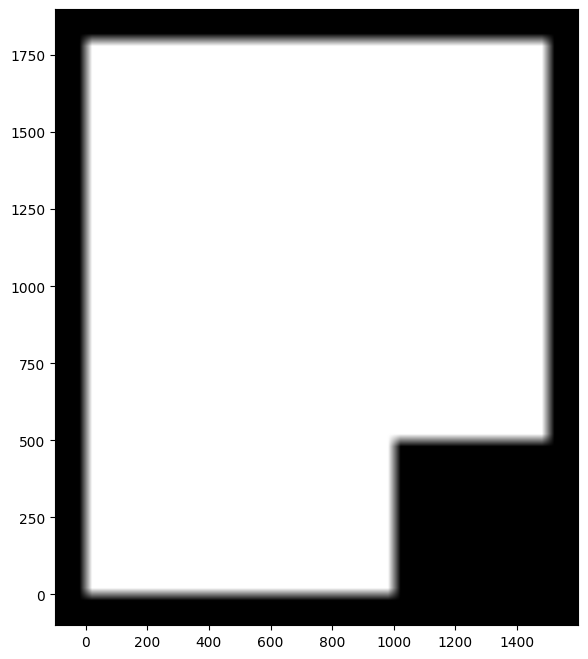

In [10]:
span = 41
blurred = cv2.blur(inside_boundary_field, (span, span))
plot_map(blurred)

In [11]:
print("World (-1, 0) = ", blurred[margin - 1, margin])
print("World (0, 0) = ", blurred[margin, margin])
print("World (21, 21) = ", blurred[margin + 21, margin + 21])
print("World (1, 0) = ", blurred[margin + 1, margin])
print("World (42, 42) = ", blurred[margin + 42, margin + 42])
print("World (-42, -42) = ", blurred[margin - 42, margin - 42])


World (-1, 0) =  0.24985129
World (0, 0) =  0.26234385
World (21, 21) =  1.0
World (1, 0) =  0.27483642
World (42, 42) =  1.0
World (-42, -42) =  1e-10


In [12]:
np.save('../robot/boundary_probabilities.npy', blurred)

In [13]:
corners = np.array([
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
])

edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

In [14]:
test_point = np.array([1100, 400])
test_point[::-1]

array([ 400, 1100])

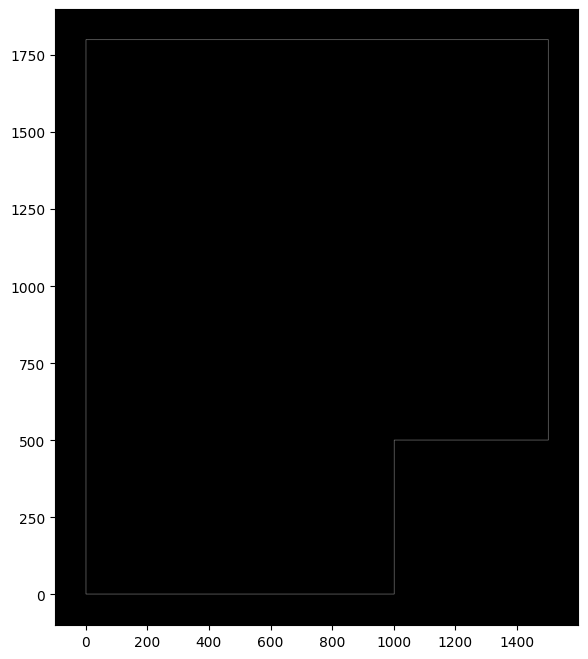

In [15]:
# Create the probability map with edges drawn as 1.0

# Todo - this is the wrong way around...

distance_field = np.full_like(wx_map, low_probability, dtype=np.float32)
for edge in edges:
    p1 = corners[edge[0]] + (margin, margin)
    p2 = corners[edge[1]] + (margin, margin)
    cv2.line(distance_field, p1[::-1], p2[::-1], color=1.0, thickness=1)
# distance_field = distance_field
plot_map(distance_field)

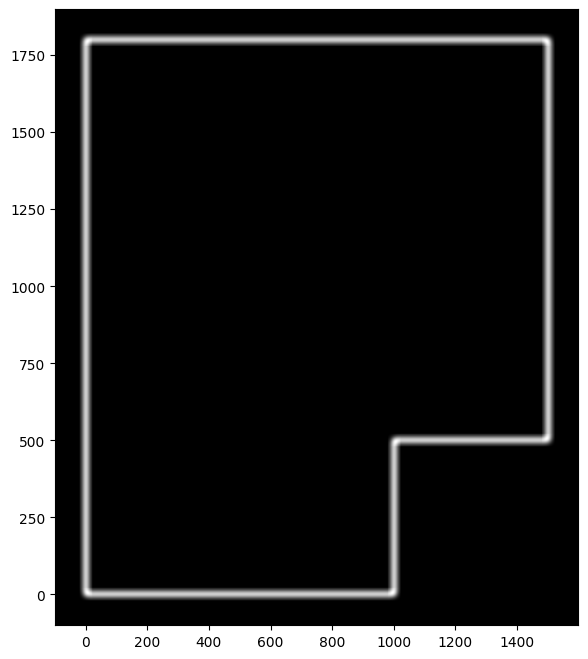

In [16]:
# Blur this map
distance_span = 41
blurred_distance = cv2.GaussianBlur(distance_field, (distance_span, distance_span), 10)
plot_map(blurred_distance)